We want to solve $$ \mathrm{d} Y_t^m = \mu(Y_t^m,t) + \varsigma(Y_t^m,t) \mathrm{d} X_t^{m,-} + \sigma(Y_t^m,t) \mathrm{d} W_t^m$$ where 
- $W$ is a $d$-dimensional Brownian motion, $X$ is 1-dimensional $H$-fBm, possibly correlated with $W$; $Y$ is $n$-dimensional
- The ${}^m$ denotes piecewise-linear approximations and the ${}^-$ means lagged w.r.t. $W$ by one interval
- $\mu$ and $\varsigma$ take values in $\mathbb R^n$, $\sigma$ takes values in $\mathbb R^{n \times d}$

We begin by focusing on the case of $H = 1/2$ and $\mathrm{d}[X,W^k]_t = \rho^k \mathrm{d}t$ for some $\rho^k \in [-1,1]$. The equation then becomes $$ \mathrm{d}Y_t = \Big( \mu(Y_t,t) + \frac{\rho^k}{2}[\sigma_k,\varsigma](Y_t,t) \Big)\mathrm{d}t + \varsigma(Y_t,t) \circ \mathrm{d}X_t^- + \sigma(Y_t,t) \circ \mathrm{d}W_t $$ where $[\sigma_k,\varsigma]$ denotes the Lie bracket $\mathrm{D}\varsigma \sigma_k - \mathrm{D}\sigma_k \varsigma$. Let's take $d = 3$ and $\rho^k = \delta^{1k}$.

In [174]:
# Imports
import jax
import jax.random as jr
import jax.numpy as jnp
import matplotlib.pyplot as plt
from diffrax import diffeqsolve, ControlTerm, Euler, Heun, Midpoint, MultiTerm, ODETerm, SaveAt, VirtualBrownianTree

In [237]:
# Global parameters, create brownian path(s)
t0, t1 = 0, 10
epsilon = 0.05
times = jnp.arange(t0, t1, epsilon)
vbt = VirtualBrownianTree(t0, t1, tol=epsilon, shape=(1,), key=jr.PRNGKey(0))
bm_control = vbt.evaluate

bm_control(1)

# Note that here I am only retaining the method evaluate from VirtualBrownianTree. This is because it's the only one
# being used later on. But on should make sure nothing is being thrown out. From now on a "control" will be a
# a function that returns the increment: (s,t) |-> X_t - X_s.

Array([1.3320228], dtype=float32)

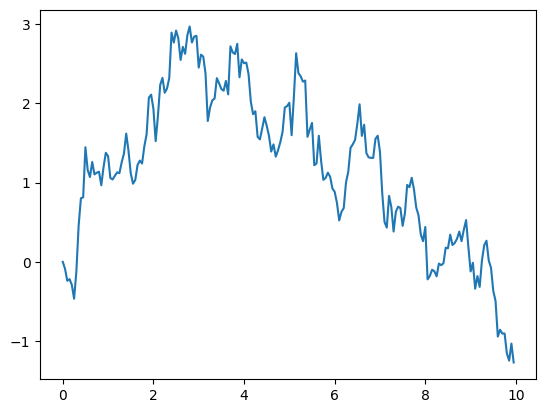

In [238]:
# Transform control (like brownian_motion, or more generally any function) to array, so that it can be plotted
def fun_to_array(grid, fun):
    return jax.vmap(lambda t: fun(t))(grid)
bm_array = fun_to_array(times, bm_control)
plt.plot(times,bm_array)
plt.show()

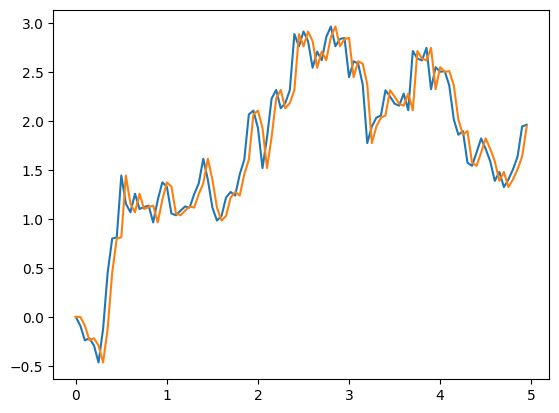

In [239]:
# Create lagged control from a given control and join them
def lagged_control(fun, lag):
    return lambda s,t: fun(jnp.maximum(0,t - lag)) - fun(jnp.maximum(0,s - lag))
lagged_bm_control = lagged_control(bm_control, epsilon)

def join_controls(lagged, original):
    return lambda s,t: jnp.concatenate((lagged(s,t), original(s,t)))

lead_lag_control = join_controls(bm_control, lagged_bm_control)

# Plot them side by side on a small interval
s0, s1 = 0, 100
lead_lag_array = fun_to_array(times, lambda t: lead_lag_control(0,t))
plt.plot(times[s0:s1],lead_lag_array[s0:s1])
plt.show()

In [14]:
# Do a simple example 1-dimensional ODE
# Solver with symbolic coefficients for n-dimensional

Let's start with $X$ and $W$ equal and 1-dimensional. $ \mathrm{d} Y_t^m = \varsigma(Y_t^m) \mathrm{d} X_t^{m,-} + \sigma(Y_t^m) \mathrm{d} W_t^m$ converges to $$ \mathrm{d}Y_t = (\sigma(Y_t) + \varsigma(Y_t)) \circ \mathrm{d}W_t + \frac{1}{2}[\sigma_k,\varsigma](Y_t,t) \mathrm{d}t. $$ Let's compare the solution to the approximating CDE with that to $\mathrm{d}Y_t = (\sigma(Y_t) + \varsigma(Y_t)) \circ \mathrm{d}W_t^m + \frac{1}{2}[\sigma_k,\varsigma](Y_t,t) \mathrm{d}t$.



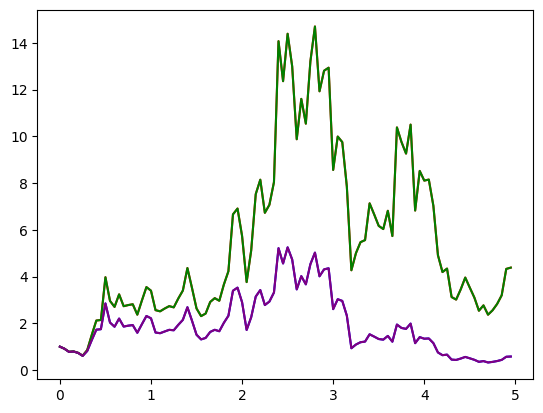

In [248]:
# First let's compare some of the solvers

diffusion = lambda t, y, args: jnp.array([y])
terms = ControlTerm(diffusion, bm_control)
solverEuler = Euler()
saveat = SaveAt(dense=True)
y0 = 1

# Euler, with finer grid than was used to generate the brownian motion
sol_euler_finer = diffeqsolve(terms, solverEuler, t0, t1, dt0 = epsilon*0.05, y0=y0, saveat=saveat)
euler_finer_array = fun_to_array(times, sol_euler_finer.evaluate)

# Euler, with the same grid as was used to generate the brownian motion
sol_euler_same = diffeqsolve(terms, solverEuler, t0, t1, dt0 = epsilon, y0=y0, saveat=saveat)
euler_same_array = fun_to_array(times, sol_euler_same.evaluate)

solverHeun = Midpoint()

# Heun, with the finer grid as was used to generate the brownian motion
sol_heun_finer = diffeqsolve(terms, solverHeun, t0, t1, dt0 = epsilon*0.05, y0=y0, saveat=saveat)
heun_finer_array = fun_to_array(times, sol_euler_finer.evaluate)

# Heun, with the same grid as was used to generate the brownian motion
sol_heun_same = diffeqsolve(terms, solverHeun, t0, t1, dt0 = epsilon, y0=y0, saveat=saveat)
heun_same_array = fun_to_array(times, sol_euler_same.evaluate)


s0, s1 = 0, 100
plt.plot(times[s0:s1], euler_finer_array[s0:s1], color = "red")
plt.plot(times[s0:s1], euler_same_array[s0:s1], color = "blue")
plt.plot(times[s0:s1], heun_finer_array[s0:s1], color = "green")
plt.plot(times[s0:s1], heun_same_array[s0:s1], color = "purple")
plt.show()


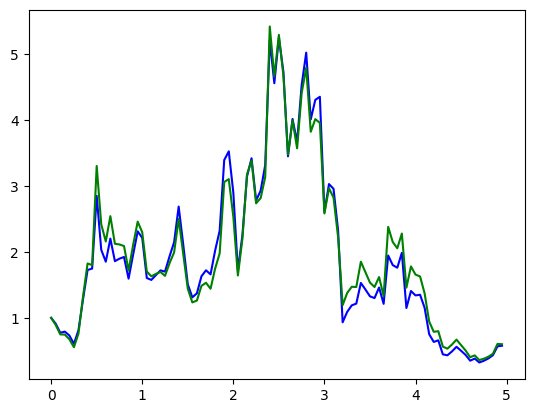

In [256]:
drift = lambda t, y, args: 0
diffusion = lambda t, y, args: y
brownian_motion = VirtualBrownianTree(t0, t1, tol=epsilon, shape=(), key=jr.PRNGKey(0))
terms = MultiTerm(ODETerm(drift), ControlTerm(diffusion, brownian_motion))
ito_solver = Euler()
strat_solver = Heun()
saveat = SaveAt(dense=True)
ito_sol = diffeqsolve(terms, ito_solver, t0, t1, dt0 = epsilon, y0=y0, saveat=saveat)
strat_sol = diffeqsolve(terms, strat_solver, t0, t1, dt0 = epsilon*0.05, y0=y0, saveat=saveat)
ito_sol_array = fun_to_array(times, ito_sol.evaluate)
strat_sol_array = fun_to_array(times, strat_sol.evaluate)

def ito_sol_true(bm):
    return lambda t: jnp.exp(bm(t) - t/2)

def strat_sol_true(bm):
    return lambda t: jnp.exp(bm(t))

ito_true_array = fun_to_array(times, ito_sol_true(bm_control))
strat_true_array = fun_to_array(times, strat_sol_true(bm_control))


plt.plot(times[s0:s1], ito_sol_array[s0:s1], color = "blue")
plt.plot(times[s0:s1], ito_true_array[s0:s1], color = "green")
#plt.plot(times[s0:s1], strat_sol_array[s0:s1], color = "red")
#plt.plot(times[s0:s1], strat_true_array[s0:s1], color = "orange")
plt.show()


Diffrax recommends taking the step size of the solver coarser than the discretisation of the Brownian motion. Here, however, we would like to do the opposite. I tested whether this gives back the correct Itô and Stratonovich solution for the simple SDE $\mathrm{d}Y_t = Y_t \mathrm{d}W_t$, $Y_t = \exp(W_t-t/2)$ or $= \exp(W_t)$ depending on whether it is intended in the Itô or Stratonovich sense. The only case in which this works is using MultiTerm and the Heun solver (which converges to Stratonovich). Euler always produces an error, and only using ControlTerm also does for some reason. The only thing that works is Heun with Multiterm.

More testing is needed before moving onto the lead-lag solver (even for bm). Another option is to convert it to an ODE by differentiating using the to_ode() function.

Another problem is that max_steps is reached quite soon and cannot be increased when outputting dense solutions. We might have to change the code so as to avoid using dense solutions.